In [1]:
!pip install tensorflow

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras import backend as K

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train[Shape (60000, 28, 28)] sample patch 
 [[  0   0   7 178 252]
 [  0   0  57 252 252]
 [  0   0 198 253 190]
 [  0  76 246 252 112]
 [  0  85 252 230  25]
 [  0  85 252 223   0]
 [  0  85 252 145   0]
 [  0  86 253 225   0]]


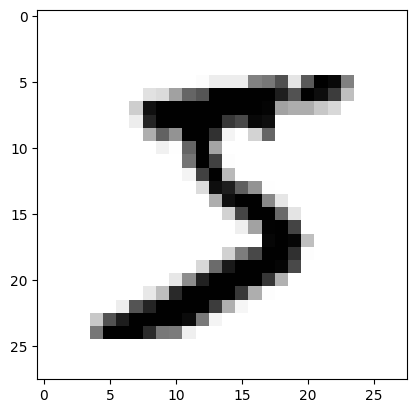

In [4]:
print("x_train[Shape %s] sample patch \n"%(str(x_train.shape)),x_train[1,12:20,5:10])
plt.imshow(x_train[0], cmap=plt.cm.binary)
plt.show()


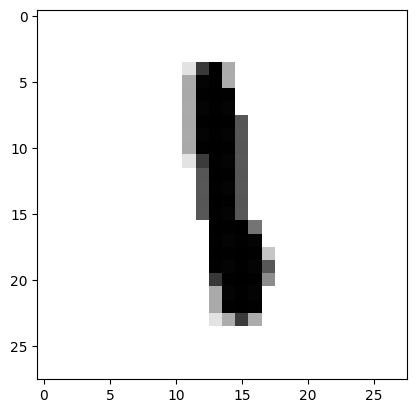

In [5]:
plt.imshow(x_train[200], cmap=plt.cm.binary)
plt.show()

In [6]:
import tensorflow as tf
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
#scale min_max scaler
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0
#flatten the images from (28*28) into 784
x_train=x_train.reshape(x_train.shape[0],-1)
x_test=x_test.reshape(x_test.shape[0],-1)
#one-hot encoding labels
y_train=tf.keras.utils.to_categorical(y_train,num_classes=10)
y_test=tf.keras.utils.to_categorical(y_test,num_classes=10)

model=tf.keras.Sequential([
    tf.keras.layers.Dense(200,activation='relu',input_shape=(784,)),
    tf.keras.layers.Dense(100,activation='relu'),
    tf.keras.layers.Dense(60,activation='relu'),
    tf.keras.layers.Dense(30,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax')
])

model.summary()

d:\somethinges\courses\DEPI\ONL4_AIS2_S2..v2\env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,300 (723.83 KB)

 Trainable params: 185,300 (723.83 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001)
,loss='categorical_crossentropy'
,metrics=['accuracy'])

In [8]:
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9100 - loss: 0.3038 - val_accuracy: 0.9564 - val_loss: 0.1501
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9636 - loss: 0.1178 - val_accuracy: 0.9668 - val_loss: 0.1123
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9754 - loss: 0.0803 - val_accuracy: 0.9698 - val_loss: 0.0963
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9823 - loss: 0.0566 - val_accuracy: 0.9712 - val_loss: 0.0994
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9851 - loss: 0.0462 - val_accuracy: 0.9719 - val_loss: 0.0954
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9877 - loss: 0.0381 - val_accuracy: 0.9654 - val_loss: 0.1287
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9896 - loss: 0.0326 - val_accuracy: 0.9725 - val_loss: 0.1025
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9900 - loss: 0.0307 - val_accuracy: 0.

In [9]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9790 - loss: 0.0941
Test Loss: 0.09412695467472076
Test Accuracy: 0.9789999723434448


In [10]:
from numpy._core.numeric import indices
import numpy as np
def get_random_indices(total_images,num_images):
  indices=np.random.choice(range(total_images),num_images,replace=False)
  indices=np.array(indices)
  return indices

In [11]:
# predictions=model.predict(x_test)
# x_test_images=x_test.reshape(-1,28,28)
# # plt.figure(figsize=(10,10))
# # for i in range(25):
# #   plt.subplot(5,5,i+1)
# #   plt.xticks([])
# #   plt.yticks([])
# #   plt.grid(False)
# #   plt.imshow(x_test_images[i],cmap=plt.cm.binary)
# #   predicted_label=np.argmax(predictions[i])
# #   true_label=np.argmax(y_test[i])
# #   if predicted_label==true_label:
# #     color='blue'
# #   else:
# #     color='red'
# #   plt.xlabel("{}({})".format(predicted_label,true_label),color=color)
# # plt.show()


In [12]:
predictions=model.predict(x_test)
x_test_images=x_test.reshape(-1,28,28)
predicted_classes=np.argmax(predictions,axis=1)
true_classes=np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step


In [13]:
num_images_to_show=5
random_indices=get_random_indices(len(x_test_images),num_images_to_show)
def plot_images(images,labels,predicted):
  num_to_plot = len(images)
  plt.figure(figsize=(10,10))
  for i in range(num_to_plot):
    plt.subplot(1, num_to_plot, i+1)
    plt.imshow(images[i],cmap='gray')
    plt.title(f"True:{labels[i]}, \n Predicted:{predicted[i]}")
    plt.axis('off')
  plt.tight_layout()
  plt.show()

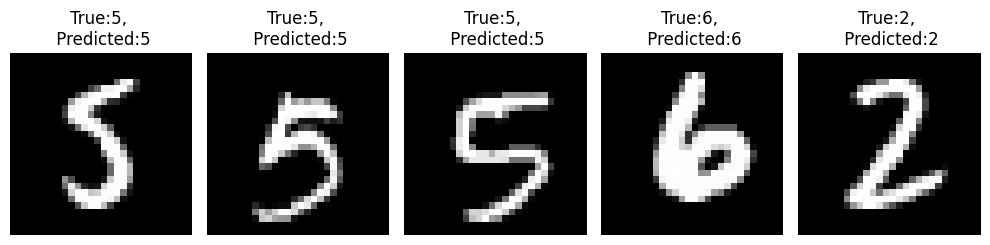

In [14]:
plot_images(x_test_images[random_indices],true_classes[random_indices],predicted_classes[random_indices])

In [15]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard
NAME='minist-28-28-v1'
tensorboard=TensorBoard(log_dir='logs/{}'.format(NAME))
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
    tf.keras.layers.Dense(100, activation = 'relu'),
    tf.keras.layers.Dense(60, activation = 'relu'),
    tf.keras.layers.Dense(30, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
historty = model.fit(x_train,y_train, epochs =10, batch_size=64, validation_split=0.2,callbacks=[tensorboard])
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6247 - loss: 1.0863 - val_accuracy: 0.8369 - val_loss: 0.5507
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8605 - loss: 0.4634 - val_accuracy: 0.8978 - val_loss: 0.3547
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8960 - loss: 0.3479 - val_accuracy: 0.9158 - val_loss: 0.2914
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9130 - loss: 0.2924 - val_accuracy: 0.9251 - val_loss: 0.2562
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9261 - loss: 0.2488 - val_accuracy: 0.9331 - val_loss: 0.2267
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9362 - loss: 0.2134 - val_accuracy: 0.9462 - val_loss: 0.1926
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9457 - loss: 0.1839 - val_accuracy: 0.9505 - val_loss: 0.1755
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9531 - loss: 0.1585 - val_accuracy: 0.

In [20]:
!pip install tensorboard

!pip show tensorboard
!pip install tensorboard --- IGNORE ---
!pip install pkg_resources


Name: tensorboard
Version: 2.20.0
Summary: TensorBoard lets you watch Tensors Flow
Home-page: https://github.com/tensorflow/tensorboard
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: D:\somethinges\courses\DEPI\ONL4_AIS2_S2..v2\env\Lib\site-packages
Requires: absl-py, grpcio, markdown, numpy, packaging, pillow, protobuf, setuptools, tensorboard-data-server, werkzeug
Required-by: tensorflow



[optparse.groups]Usage:[/]   
  pip install \[options] <requirement specifier> \[package-index-options] ...
  pip install \[options] -r <requirements file> \[package-index-options] ...
  pip install \[options] [-e] <vcs project url> ...
  pip install \[options] [-e] <local project path> ...
  pip install \[options] <archive url/path> ...

no such option: ---
ERROR: Could not find a version that satisfies the requirement pkg_resources (from versions: none)
ERROR: No matching distribution found for pkg_resources


In [32]:
!tensorboard --logdir = logs --port = 6006

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\somethinges\courses\DEPI\ONL4_AIS2_S2..v2\env\Scripts\tensorboard.exe\__main__.py", line 4, in <module>
  File "D:\somethinges\courses\DEPI\ONL4_AIS2_S2..v2\env\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "D:\somethinges\courses\DEPI\ONL4_AIS2_S2..v2\env\Lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'


In [ ]:
!tensorboard --logdir = logs --port = 6006

Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\somethinges\courses\DEPI\ONL4_AIS2_S2..v2\env\Scripts\tensorboard.exe\__main__.py", line 4, in <module>
  File "D:\somethinges\courses\DEPI\ONL4_AIS2_S2..v2\env\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "D:\somethinges\courses\DEPI\ONL4_AIS2_S2..v2\env\Lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'
